In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("/content/marketing_campaign.csv",sep ="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# EDA

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# missing values
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


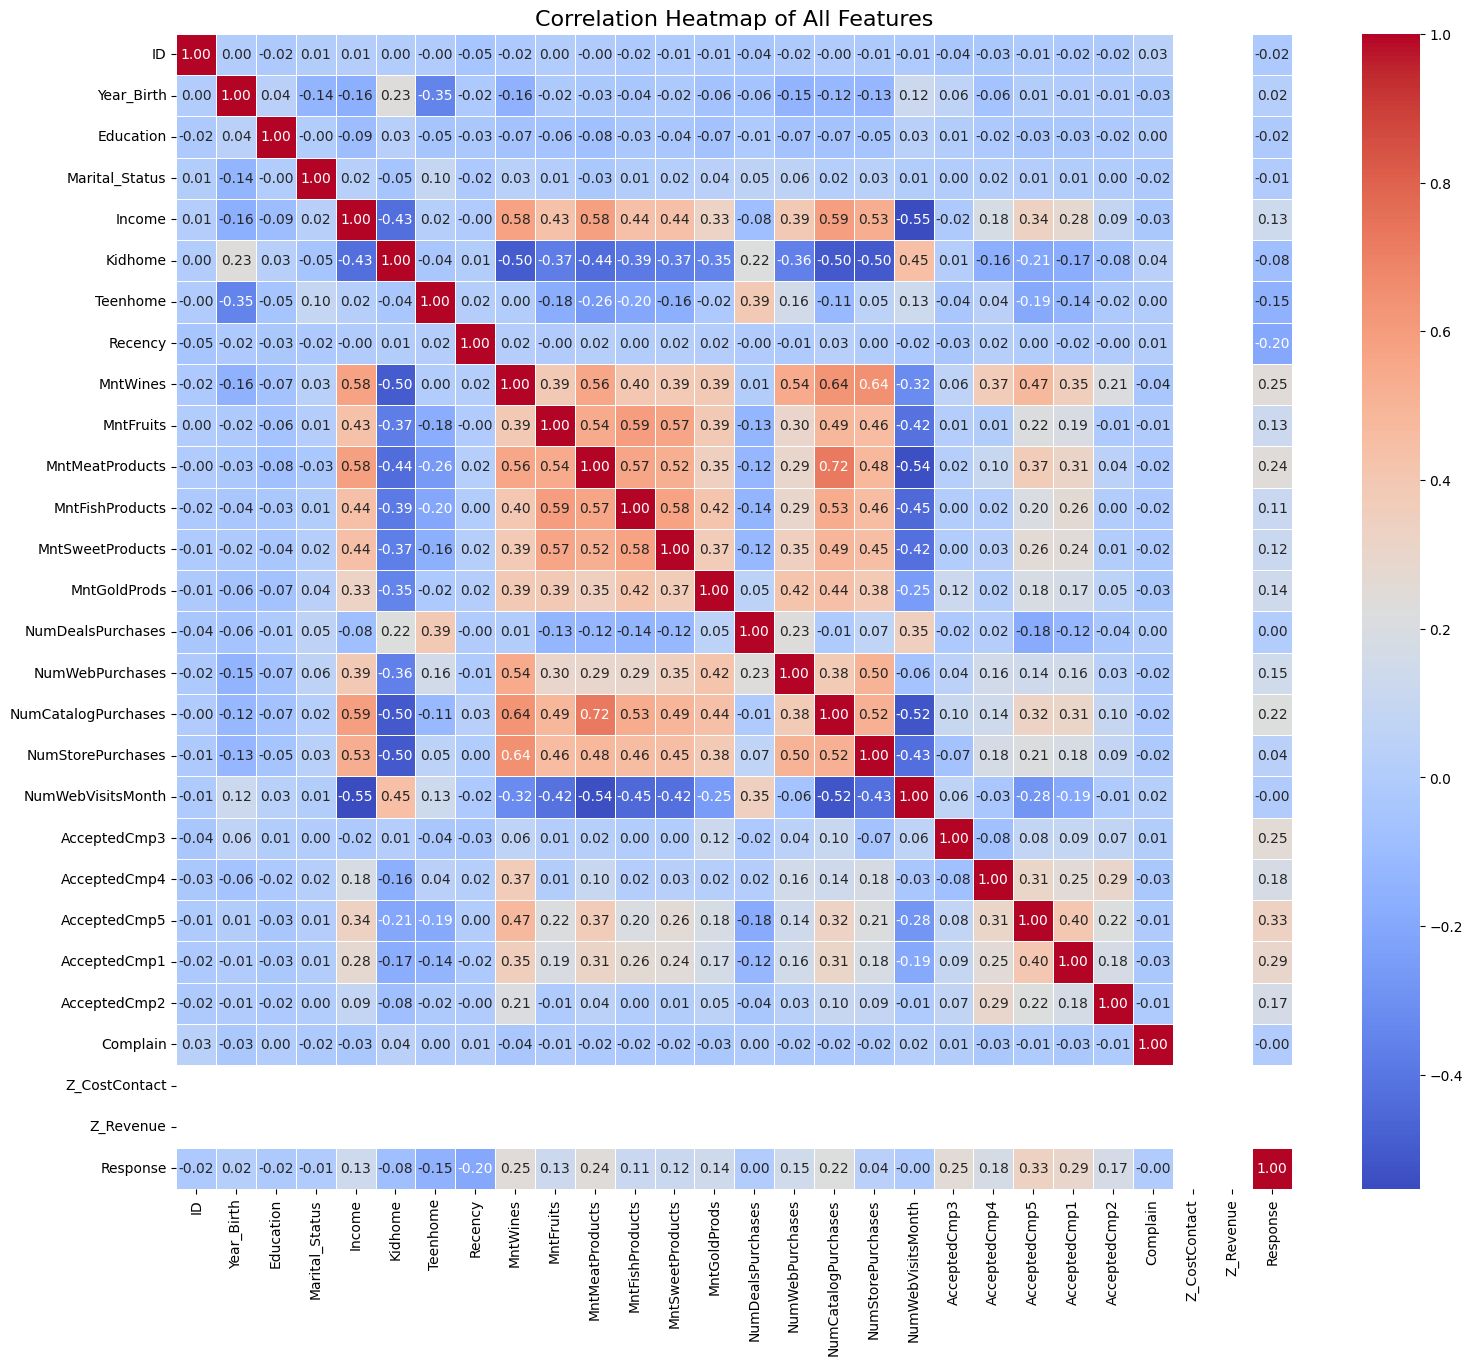

In [ ]:
plt.close('all')

df_numeric = df.copy()

categorical_cols = ['Education', 'Marital_Status']
for col in categorical_cols:
    df_numeric[col] = pd.factorize(df_numeric[col])[0]

# drop date column
df_numeric = df_numeric.drop(columns=['Dt_Customer'])

corr_all = df_numeric.corr()

plt.figure(figsize=(18,15))
sns.heatmap(
    corr_all,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of All Features", fontsize=16)
plt.show()

In [ ]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [ ]:
df = df.drop(df[df['Marital_Status'] == 'Absurd'].index)
df = df.drop(df[df['Marital_Status'] == 'YOLO'].index)
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3


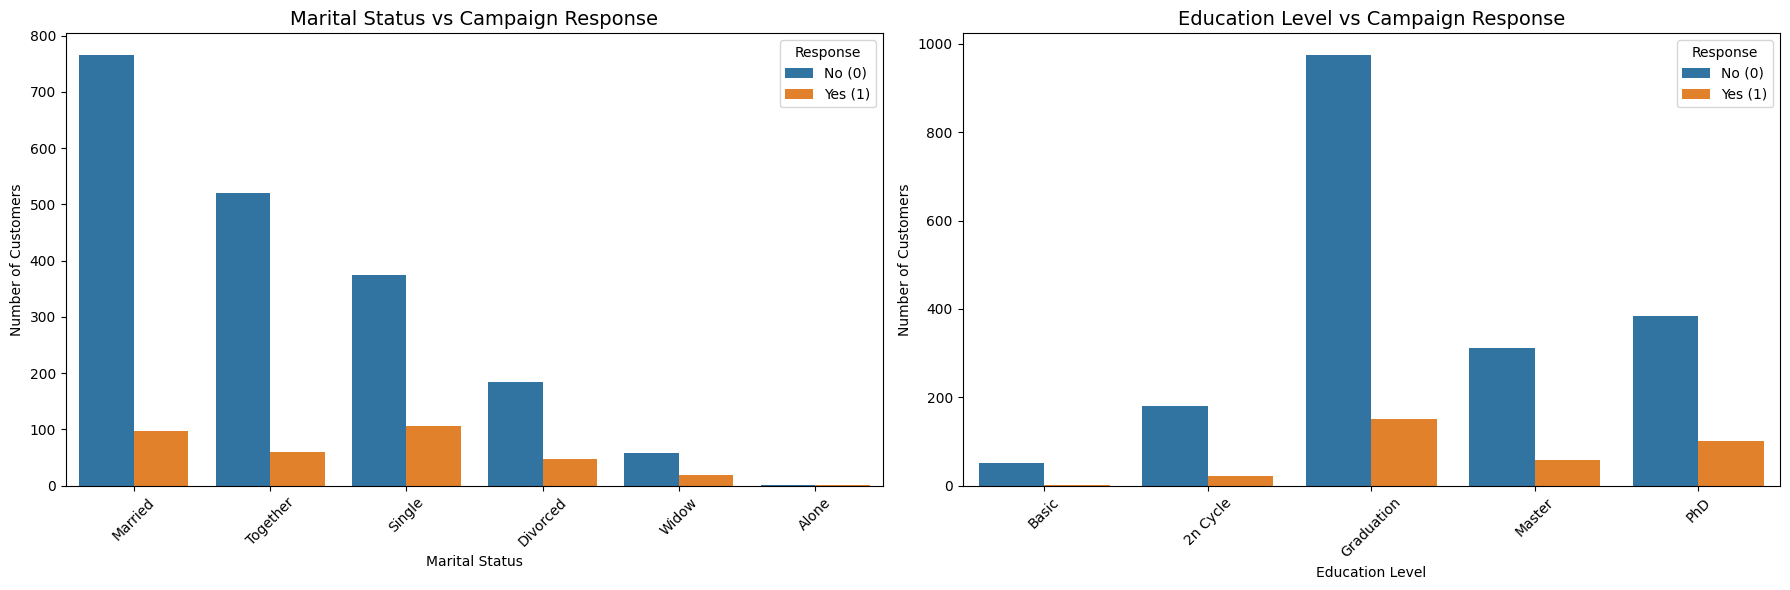

In [ ]:
plt.close('all')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#Marital Status vs Response
sns.countplot(
    data=df,
    x='Marital_Status',
    hue='Response',
    order=df['Marital_Status'].value_counts().index,
    ax=axes[0])

axes[0].set_title("Marital Status vs Campaign Response", fontsize=14)
axes[0].set_xlabel("Marital Status")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Response", labels=["No (0)", "Yes (1)"])

#Education vs Response
sns.countplot(
    data=df,
    x='Education',
    hue='Response',
    order=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'],
    ax=axes[1])

axes[1].set_title("Education Level vs Campaign Response", fontsize=14)
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Number of Customers")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Response", labels=["No (0)", "Yes (1)"])

plt.tight_layout()
plt.show()

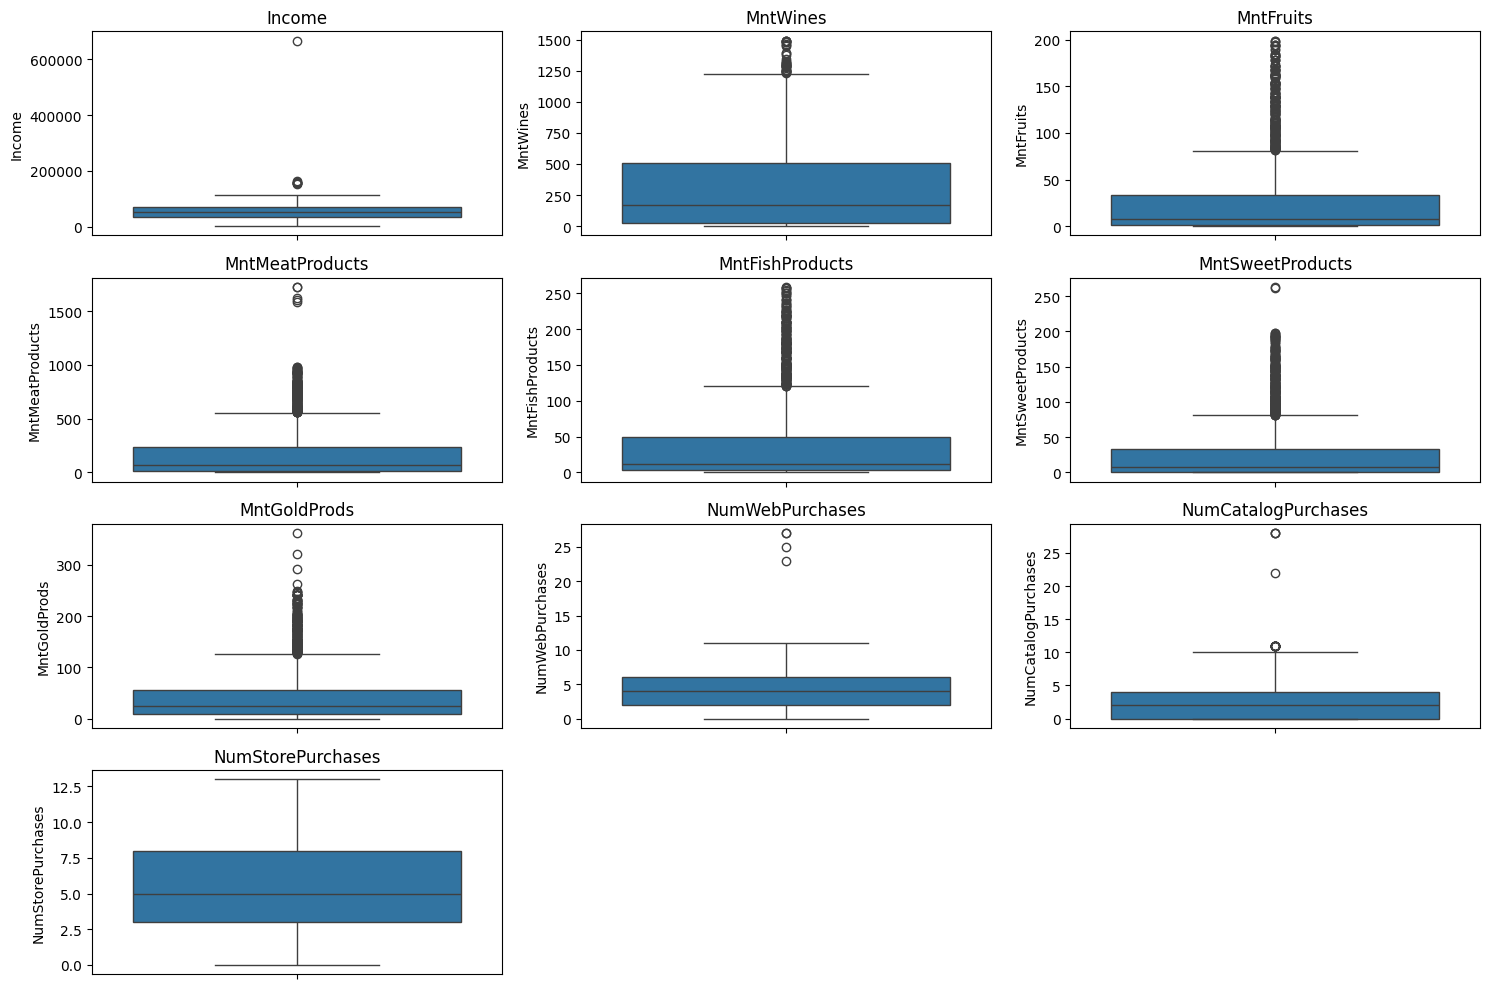

In [ ]:
#outliers before processing
numeric_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

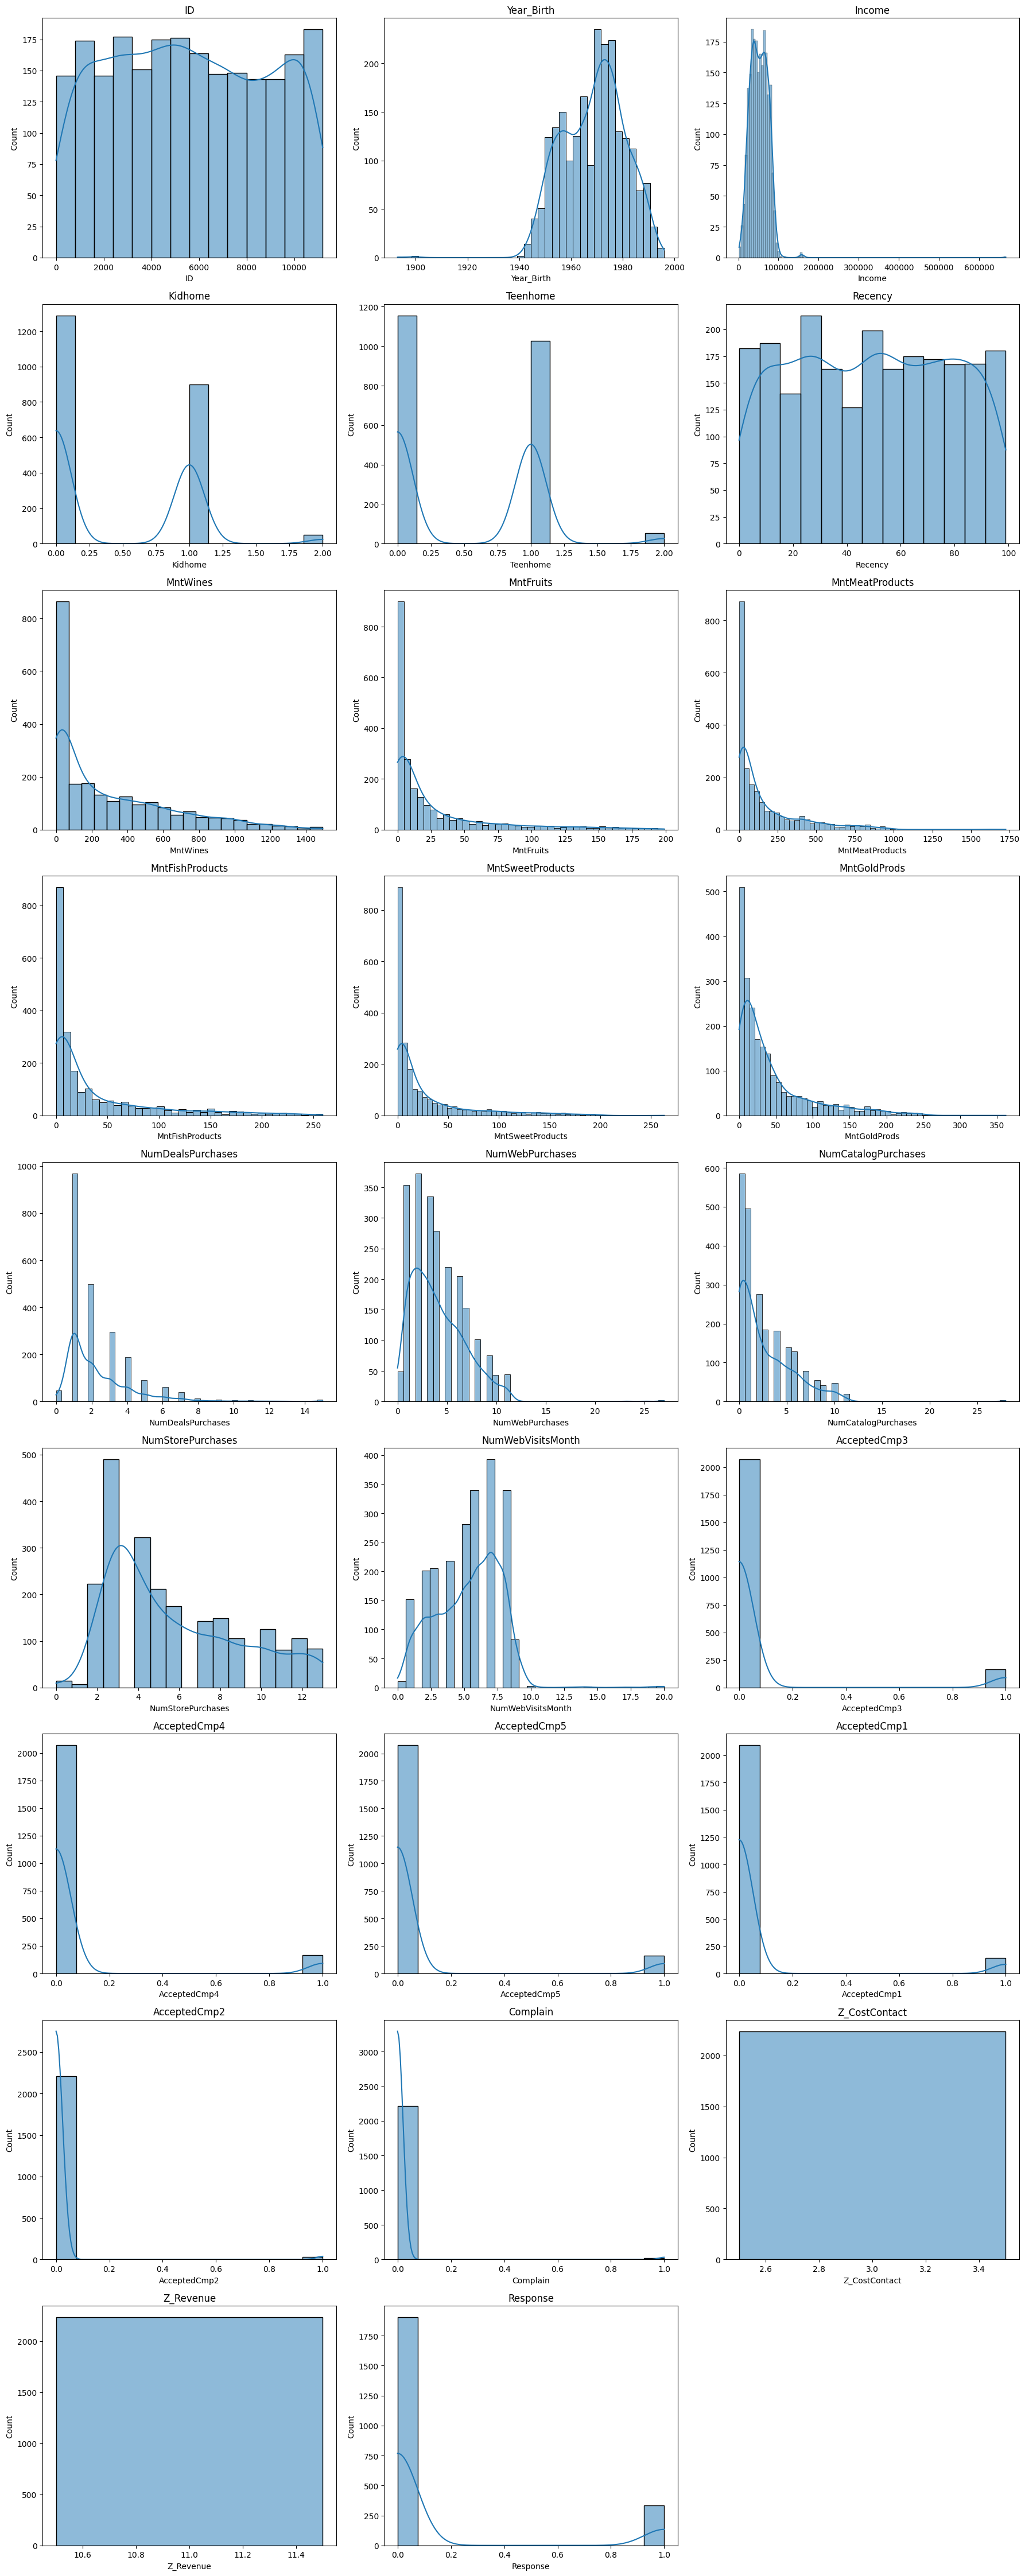

In [ ]:
#Normality Check
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

# data cleaning

In [ ]:
#convert 'id' into string
df['ID'] = df['ID'].astype(str)

#convert Dt_Customer into int
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format="%d-%m-%Y", errors='coerce')

In [ ]:
# using KNN to solve income missings

# select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# create KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)

# apply imputation
df[num_cols] = knn_imputer.fit_transform(df[num_cols])

# for check
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# Data preprocessing

In [ ]:
#processing outliers using capping
numeric_cols = ['Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']

# solving outliers for each clo
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    df[col] = df[col].apply(lambda x: upper_bound if x > upper_bound
                                         else (lower_bound if x < lower_bound else x))


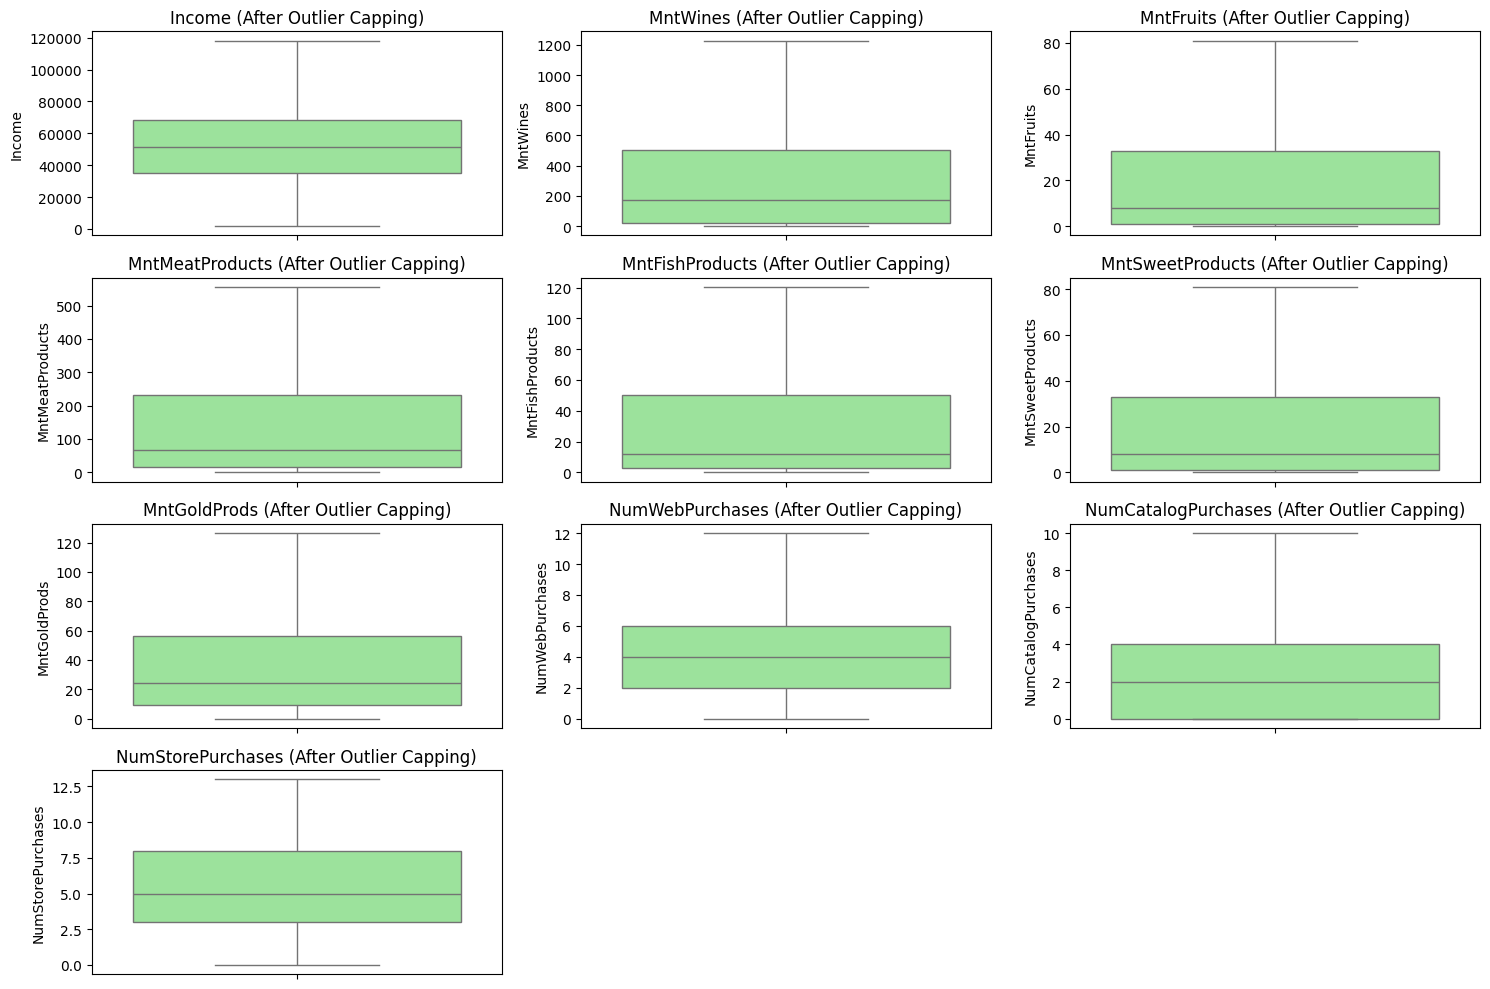

In [ ]:
#outliers after processing
plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f"{col} (After Outlier Capping)")

plt.tight_layout()
plt.show()

# Feature Engneering

In [ ]:
model_df = df.copy()

In [ ]:
#conducting age col
model_df['Age'] = 2025 - model_df['Year_Birth']

#conducting Total_Spending col
model_df['Total_Spending'] = (
    model_df['MntWines'] +
    model_df['MntFruits'] +
    model_df['MntMeatProducts'] +
    model_df['MntFishProducts'] +
    model_df['MntSweetProducts'] +
    model_df['MntGoldProds'])

#conducting Total_Purchases col
model_df['Total_Purchases'] = (
    model_df['NumDealsPurchases'] +
    model_df['NumWebPurchases'] +
    model_df['NumCatalogPurchases'] +
    model_df['NumStorePurchases'])

#conducting Family Size col
model_df['Family_Size'] = model_df['Kidhome'] + model_df['Teenhome']

# Transformation

In [ ]:
log_cols = [
    'Income',
    'MntWines','MntFruits','MntMeatProducts',
    'MntFishProducts','MntSweetProducts','MntGoldProds',
    'Total_Spending','Total_Purchases'
]

for col in log_cols:
    model_df[col] = np.log1p(model_df[col])

In [ ]:
cluster_df = model_df.drop(
    columns=[
        'ID',
        'Year_Birth',
        'Z_CostContact',
        'Z_Revenue',
        'AcceptedCmp1',
        'AcceptedCmp2',
        'AcceptedCmp3',
        'AcceptedCmp4',
        'AcceptedCmp5',
        'Response',
        'Complain',
        'Dt_Customer'
    ]
)


In [ ]:
# Encode categorical columns
le = LabelEncoder()
cluster_df['Education'] = le.fit_transform(cluster_df['Education'])
cluster_df['Marital_Status'] = le.fit_transform(cluster_df['Marital_Status'])


In [ ]:
# Scaling
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

In [ ]:
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

cluster_scaled_df = pd.DataFrame(
    cluster_scaled,
    columns=cluster_df.columns
)

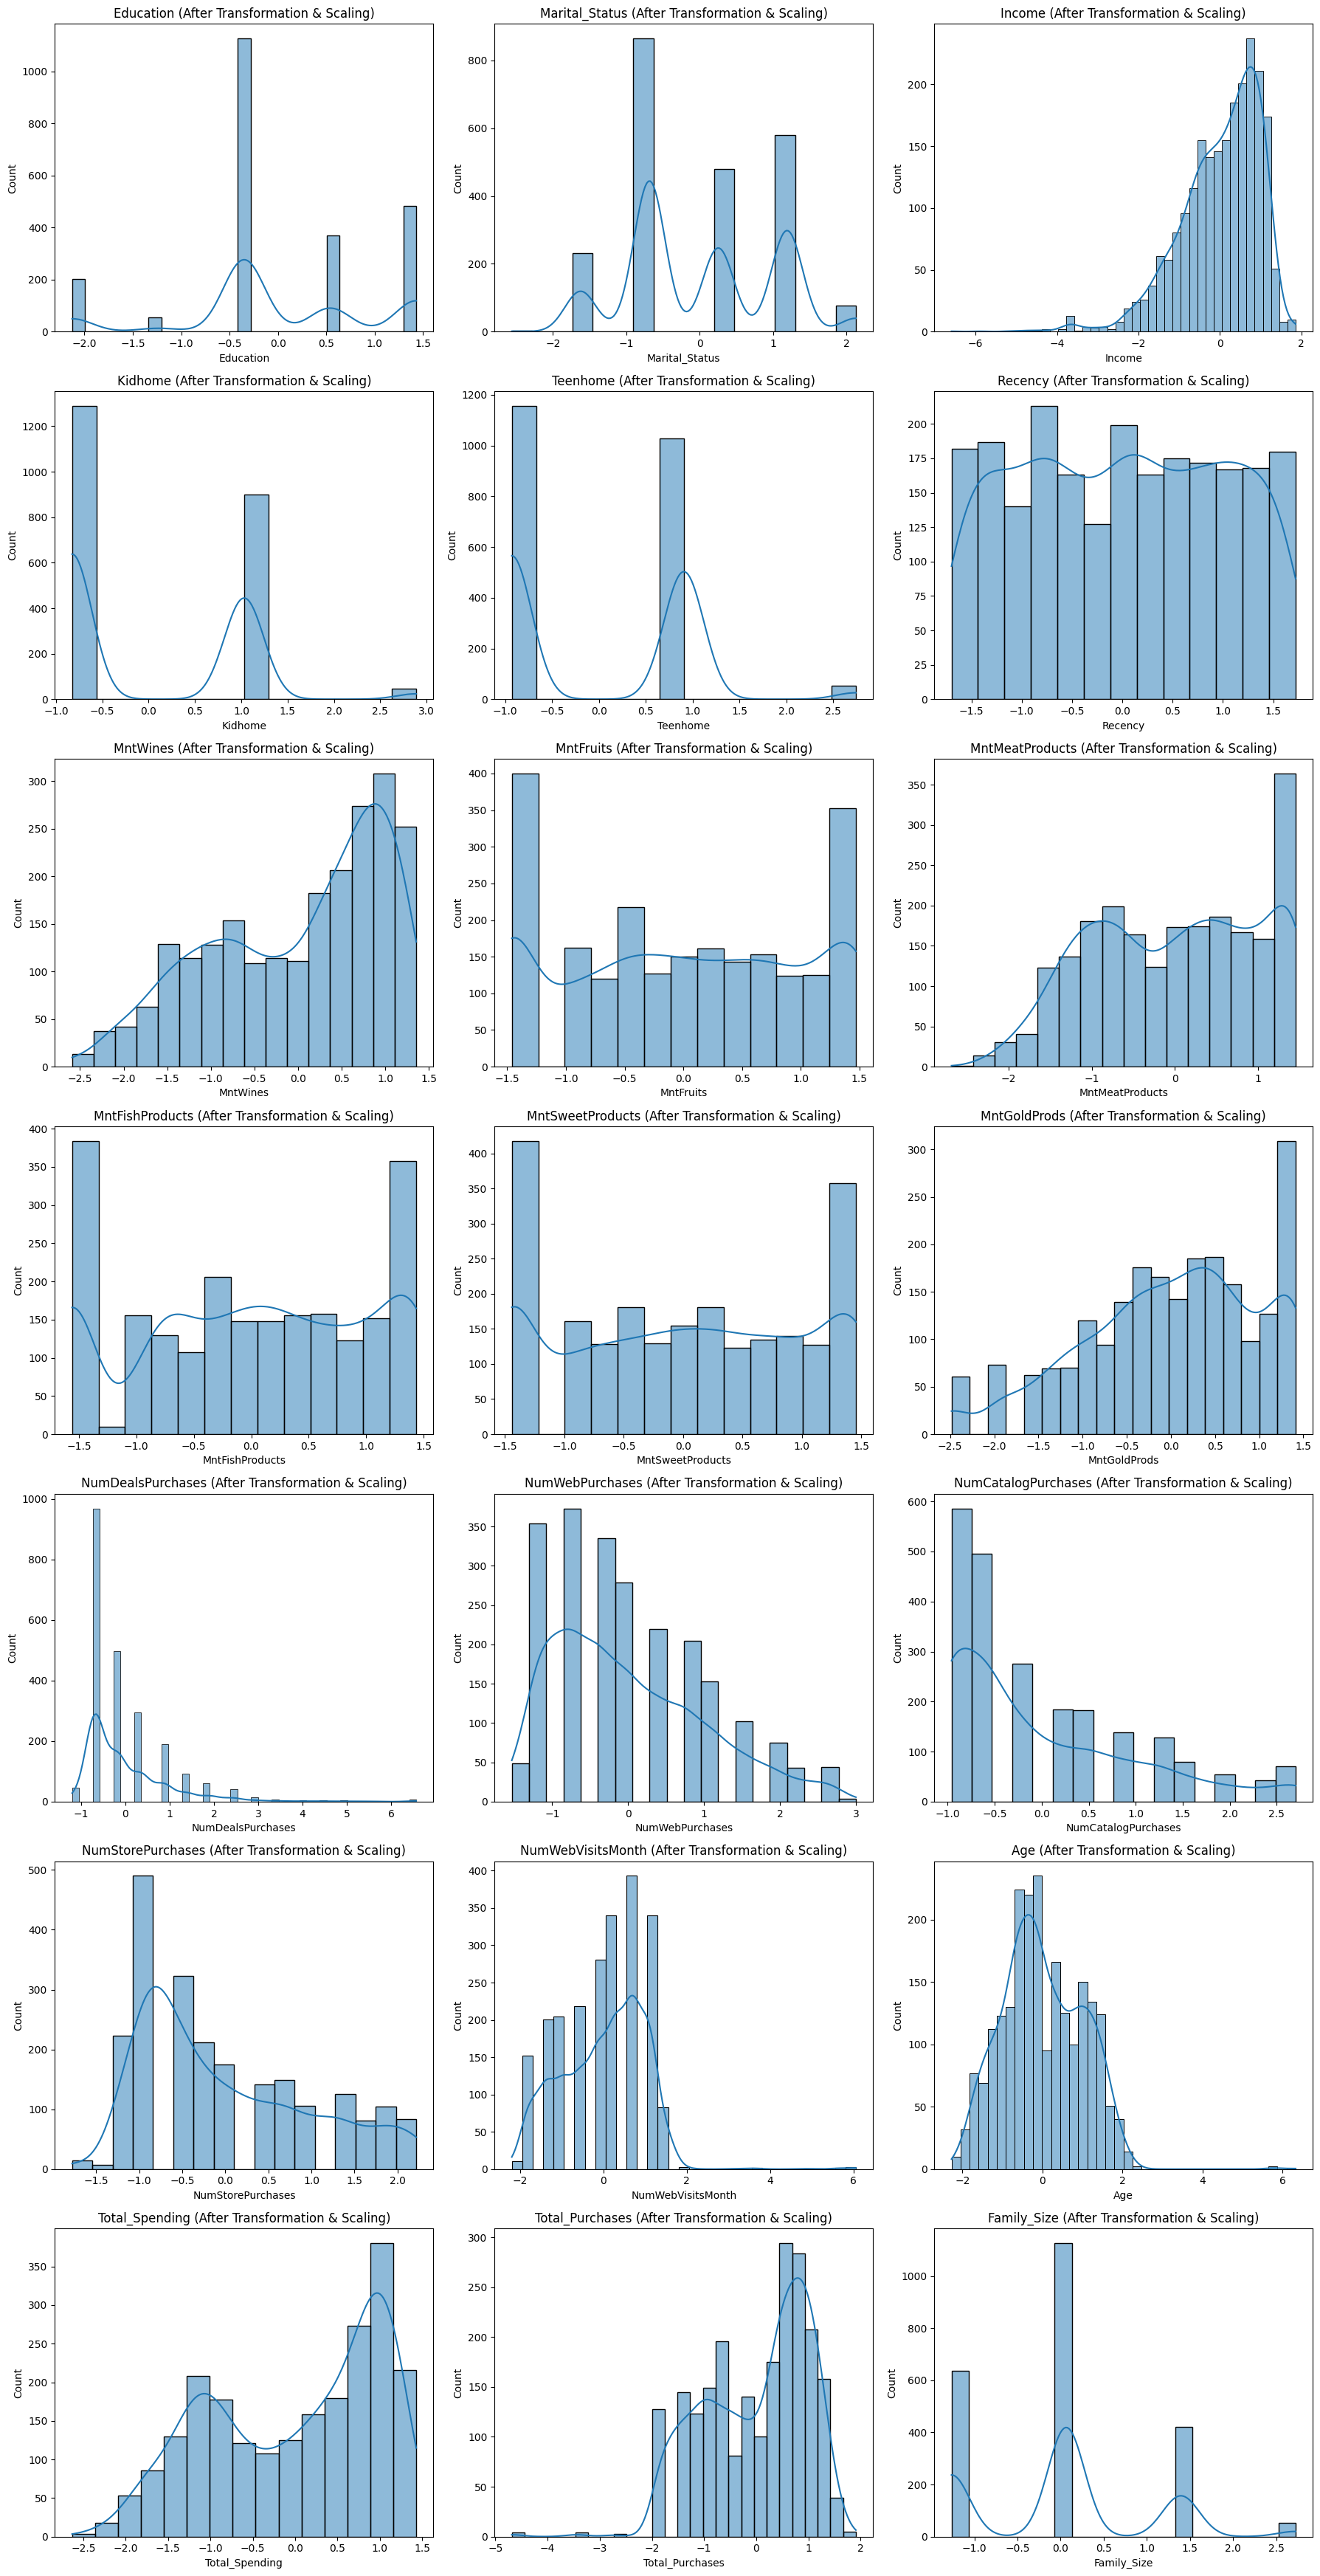

In [ ]:
num_cols = cluster_scaled_df.columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(cluster_scaled_df[col], kde=True)
    plt.title(f"{col} (After Transformation & Scaling)")

plt.tight_layout()
plt.show()


# Model selsction

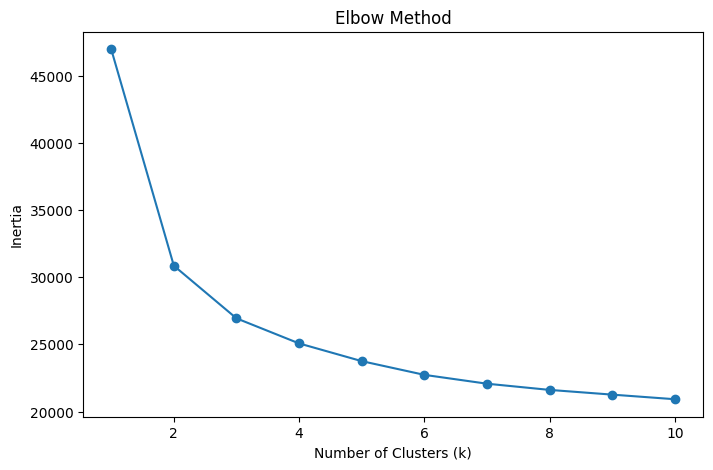

In [ ]:
#Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# Modeling

In [ ]:
# Create KMeans model with k = 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model on the scaled data and assign cluster labels
model_df['Cluster'] = kmeans.fit_predict(cluster_scaled)

# View the first few cluster assignments
model_df[['Cluster']].head()

,Cluster
0,0
1,2
2,0
3,2
4,1


<function matplotlib.pyplot.show(close=None, block=None)>

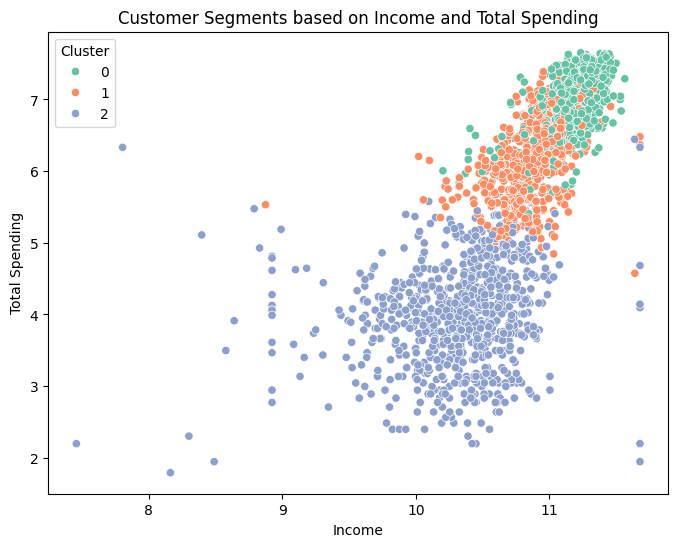

In [ ]:
#clustering based on Income vs Total Spending
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=model_df,
    x='Income',
    y='Total_Spending',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments based on Income and Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")
plt.show

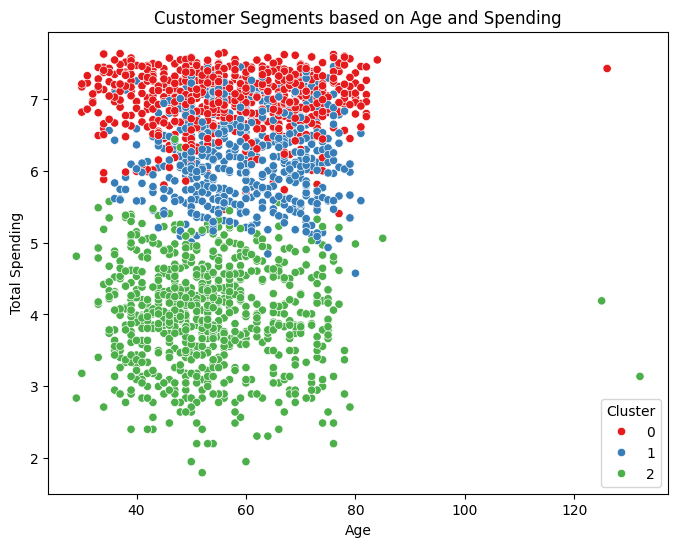

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data= model_df,
    x='Age',
    y='Total_Spending',
    hue='Cluster',
    palette='Set1')

plt.title("Customer Segments based on Age and Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")
plt.show()


/tmp/ipython-input-2903771553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


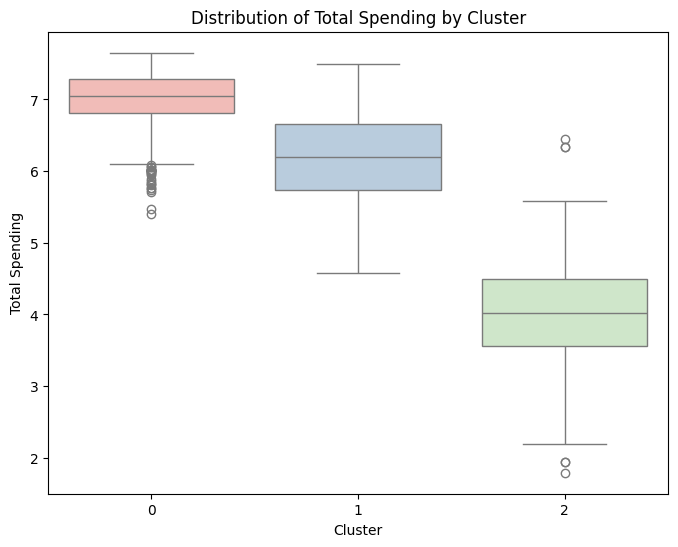

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data= model_df,
    x='Cluster',
    y='Total_Spending',
    palette='Pastel1')

plt.title("Distribution of Total Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Spending")
plt.show()


# Recommendation system

In [ ]:
cluster_profile = model_df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'Total_Purchases',
    'Age',
    'Family_Size'
]].mean()

cluster_profile

,Income,Total_Spending,Total_Purchases,Age,Family_Size
Cluster,,,,,
0,11.180105,6.998229,3.057352,57.119215,0.300140
1,10.884723,6.208027,2.956470,59.707355,1.278560
2,10.310066,4.003812,2.025950,52.932127,1.239819


In [ ]:
def marketing_recommendation(cluster):
    if cluster == 0:
        return "Offer premium products, loyalty rewards, and exclusive campaigns"
    elif cluster == 1:
        return "Use discounts, product bundles, and cross-selling strategies"
    else:
        return "Focus on promotions, coupons, and affordable products"

In [ ]:
model_df['Marketing_Recommendation'] = model_df['Cluster'].apply(marketing_recommendation)

model_df[['Cluster', 'Marketing_Recommendation']].head()


,Cluster,Marketing_Recommendation
0,0,"Offer premium products, loyalty rewards, and e..."
1,2,"Focus on promotions, coupons, and affordable p..."
2,0,"Offer premium products, loyalty rewards, and e..."
3,2,"Focus on promotions, coupons, and affordable p..."
4,1,"Use discounts, product bundles, and cross-sell..."


/tmp/ipython-input-2528757879.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


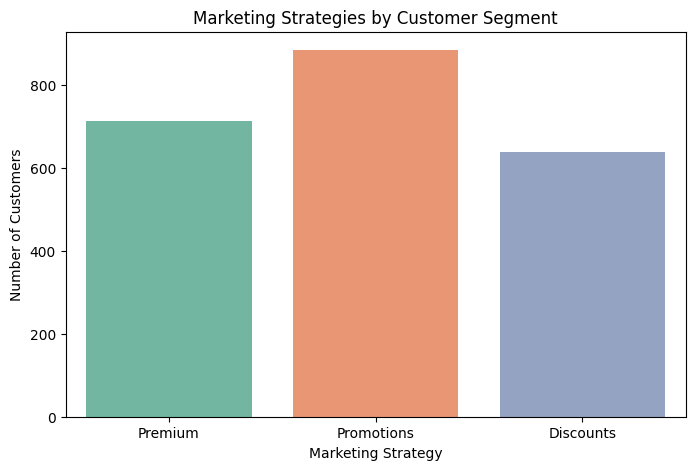

In [ ]:
model_df['Strategy_Short'] = model_df['Cluster'].map({
    0: 'Premium',
    1: 'Discounts',
    2: 'Promotions'})

plt.figure(figsize=(8,5))
sns.countplot(
    data=model_df,
    x='Strategy_Short',
    palette='Set2'
)

plt.title("Marketing Strategies by Customer Segment")
plt.xlabel("Marketing Strategy")
plt.ylabel("Number of Customers")

plt.show()

# Response Prediction Using Random Forest


In [ ]:
# Features
X = model_df[
    ['Income', 'Total_Spending', 'Total_Purchases', 'Age', 'Family_Size']
]

# Target
y= model_df['Response']


In [ ]:
X.head(10)
y.head(10)

,Response
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,1.0
9,0.0


In [ ]:
X_train  ,X_test , Y_train , Y_test = train_test_split(X , y , test_size=0.25 ,stratify=y, random_state=1)
print (X.shape  , X_train.shape , X_test.shape)

(2236, 5) (1677, 5) (559, 5)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier (n_estimators=200 , random_state = 42, class_weight = 'balanced')
RF_model.fit(X_train , Y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
Y_test_prediction = RF_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report , confusion_matrix
print(classification_report (Y_test ,Y_test_prediction))
confusion_matrix (Y_test  , Y_test_prediction)

              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92       476
         1.0       0.53      0.19      0.28        83

    accuracy                           0.86       559
   macro avg       0.70      0.58      0.60       559
weighted avg       0.82      0.86      0.82       559



array([[462,  14],
       [ 67,  16]])

462 --> Tn

16 --> Tp

67 --> Fn

14 --> Fp

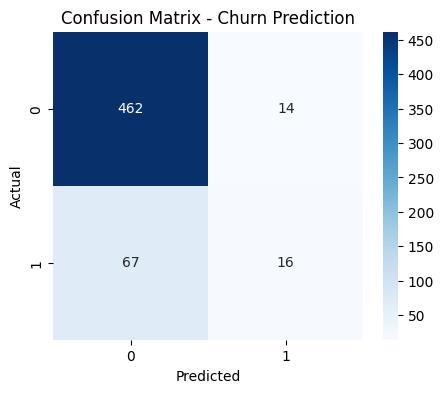

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_test_prediction)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Churn Prediction")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RF_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
1,Total_Spending,0.302283
0,Income,0.299043
3,Age,0.185828
2,Total_Purchases,0.160882
4,Family_Size,0.051965


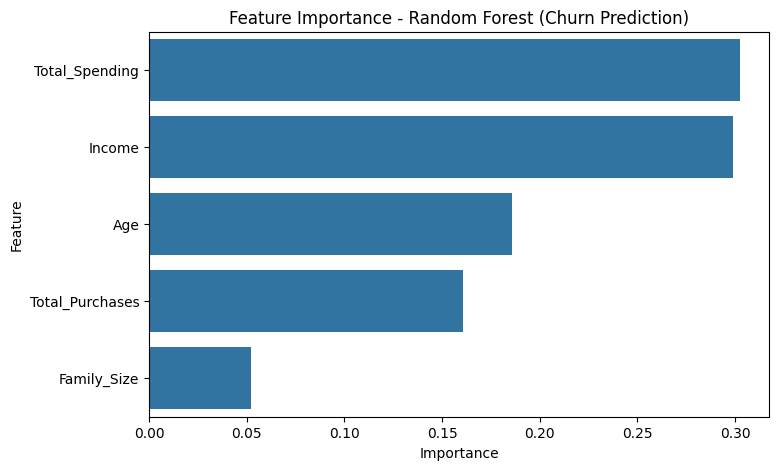

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance - Random Forest (Churn Prediction)")
plt.show()